# Matrix-Function Spectral Baselines

This notebook benchmarks dense spectral matrix function (DSMF) references and polynomial matrix evaluation (PME) approximations for physics-style operators used in filtering, thermal weighting, and diffusion examples.

In [1]:
from pathlib import Path

import numpy as np

from qsvt import (
    design_filter_polynomial,
    design_imaginary_time_polynomial,
    dirichlet_laplacian_1d,
    plot_benchmark_timings,
    plot_qsvt_proxy_resources,
    polynomial_matrix_function_benchmark,
    save_report,
    spectral_matrix_function_benchmark,
    write_benchmark_summary_csv,
)


def find_repo_root(start=Path.cwd()):
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("could not locate repository root")


ROOT = find_repo_root()
ARTIFACT_DIR = ROOT / "results/benchmarks"
TABLE_DIR = ROOT / "results/tables"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)


def fmt(value):
    if value is None:
        return "n/a"
    if isinstance(value, (list, tuple, set)):
        return ", ".join(fmt(item) for item in value)
    if isinstance(value, float):
        if value == 0.0:
            return "0"
        if abs(value) < 1e-3 or abs(value) >= 1e4:
            return f"{value:.2e}"
        return f"{value:.4g}"
    return str(value)


def display_table(title, rows, columns):
    rendered = [
        [str(header), *[fmt(accessor(row)) for row in rows]]
        for header, accessor in columns
    ]
    widths = [max(len(item) for item in row) for row in rendered]

    print(title)
    print("-" * len(title))
    for row, width in zip(rendered, widths):
        print(f"{row[0]:<{width}} : " + " | ".join(row[1:]))

## Heat-Flow And Filter Operators

## Quantum-Advantage Interpretation

DSMF diagonalizes the full operator, which is reliable for small validation problems but scales poorly for large sparse Hamiltonians or PDE discretizations. QSVT is most relevant when the target transformation admits a moderate-degree PME and the application only needs a transformed state, filtered subspace statistic, or expectation value. These benchmarks separate the exact classical spectral baseline from the polynomial/QSVT resource proxy so the degree and signal-call assumptions remain visible.

Matrix-function benchmark readout
---------------------------------
Spectral baseline problem   : exponential-matrix-function
Thermal polynomial degree : 10
Filter polynomial degree : 10
Filter QSVT signal calls : 10


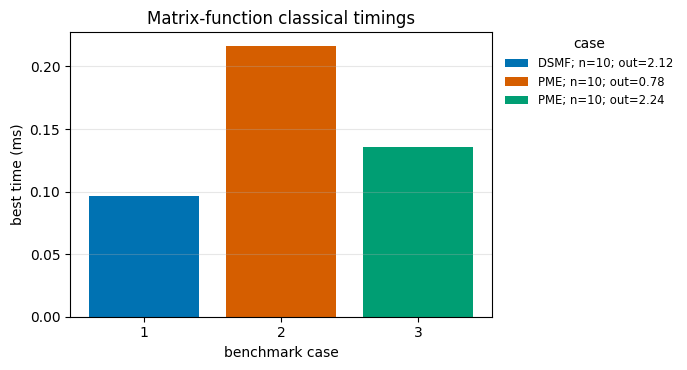

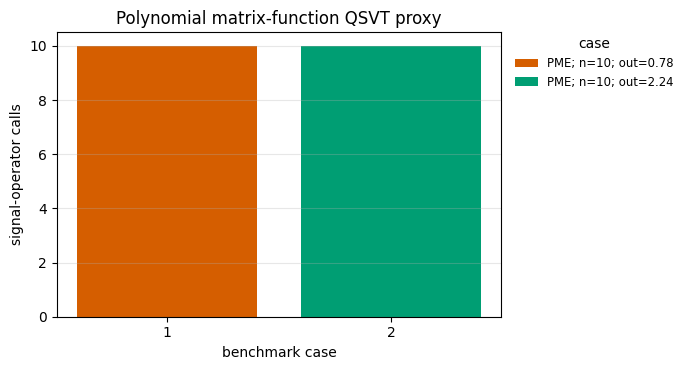

In [2]:
grid, operator = dirichlet_laplacian_1d(10)
scaled_operator = operator / np.max(np.linalg.eigvalsh(operator))

thermal = design_imaginary_time_polynomial(beta=1.0, scale=1.0, degree=10)
filter_coeffs = design_filter_polynomial(cutoff=0.35, degree=10, sharpness=10.0)

spectral_report = spectral_matrix_function_benchmark(
    scaled_operator,
    "exponential",
    beta=1.0,
    repeats=3,
)
thermal_poly_report = polynomial_matrix_function_benchmark(
    scaled_operator,
    thermal.coeffs,
    repeats=3,
)
filter_poly_report = polynomial_matrix_function_benchmark(
    scaled_operator,
    filter_coeffs,
    repeats=3,
)

reports = [spectral_report, thermal_poly_report, filter_poly_report]
save_report(spectral_report, ARTIFACT_DIR / "matrix_function_exponential_spectral.json")
save_report(
    thermal_poly_report, ARTIFACT_DIR / "matrix_function_thermal_polynomial.json"
)
save_report(filter_poly_report, ARTIFACT_DIR / "matrix_function_filter_polynomial.json")
write_benchmark_summary_csv(
    reports, TABLE_DIR / "matrix_function_benchmark_summary.csv"
)

summary = {
    "spectral_problem": spectral_report["problem"],
    "thermal_degree": thermal_poly_report["metrics"]["polynomial_degree"],
    "filter_degree": filter_poly_report["metrics"]["polynomial_degree"],
    "filter_qsvt_signal_calls": filter_poly_report["qsvt_proxy"]["resources"][
        "signal_operator_calls"
    ],
}
display_table(
    "Matrix-function benchmark readout",
    [summary],
    [
        ("Spectral baseline problem", lambda row: row["spectral_problem"]),
        ("Thermal polynomial degree", lambda row: row["thermal_degree"]),
        ("Filter polynomial degree", lambda row: row["filter_degree"]),
        ("Filter QSVT signal calls", lambda row: row["filter_qsvt_signal_calls"]),
    ],
)

_ = plot_benchmark_timings(reports, title="Matrix-function classical timings")
_ = plot_qsvt_proxy_resources(reports, title="Polynomial matrix-function QSVT proxy")